## Model Predictive Control Example

Consider the following model predictive control [1], [2] example. To determine the optimal control input $u \in \mathbb{R}^m$ applied to the linear time-invariant (LTI) system $\left( A, B\right) \in \left( \mathbb{R}^{n \times n}, \mathbb{R}^{n \times m} \right)$ with state $x \in \mathbb{R}^n$, we solve the optimization problem

\begin{equation}
\begin{array}{ll}
\text{minimize} \quad & x_H^T P x_H + \sum_{i=0}^{H-1} x_i^T Q x_i + u_i^T R u_i\\
\text{subject to} \quad &x_{i+1} = A x_i + B u_i \quad \forall i \in \{0, ..., H-1\} \\
& \Vert u_i \Vert_\infty \leq 1 \quad \forall i \in \{0, ..., H-1\} \\
& x_0 = x_\mathrm{init}, \\
\end{array}
\end{equation}

where $x_i \in \mathbb{R}^n$ and $u_i \in \mathbb{R}^m$ are the variables. The prediction horizon is $H$, the control input is constrained within a box of size $1$ and the cost matrices are positive definite: $P, Q, R \in \mathbb{S}_{++}^n, \mathbb{S}_{++}^n, \mathbb{S}_{++}^m$. Usually, $P$ is chosen as the solution to the discrete-time algebraic Riccati equation for the given LTI system and cost matrices $Q, R$. The initial measured state is $x_\mathrm{init}$. We arrange the state and input variables to matrices $X$ and $U$ with $X_{:,i} = x_i$ and $U_{:,i} = u_i$, respectively, and reformulate the problem to be [DPP-compliant](https://www.cvxpy.org/tutorial/advanced/index.html#disciplined-parametrized-programming), i.e.,

\begin{equation}
\begin{array}{ll}
\text{minimize} \quad & \Vert P^{1/2} X_{:,H} \Vert_2^2 + \Vert Q^{1/2} X_{:,0:H-1} \Vert_F^2 + \Vert R^{1/2} U \Vert_F^2\\
\text{subject to} \quad &X_{:,1:H} = A X_{:,0:H-1} + B U \\
& | U | \leq \mathbb{1} \\
& X_{:,0} = x_\mathrm{init}, \\
\end{array}
\end{equation}

with variables $X \in \mathbb{R}^{n \times H+1}$ and $U \in \mathbb{R}^{m \times H}$. Note that $|U|$ denotes the element-wise absolute value of $U$.

Let's define the corresponding CVXPY problem.

In [1]:
import cvxpy as cp

# MAXIMUM HARDWARE HORIZON: H=42 keeps constraints <= 1024
H, n, m = 42, 6, 3

# define variables
U = cp.Variable((m, H), name='U')
X = cp.Variable((n, H+1), name='X')

# define parameters
Psqrt = cp.Parameter((n, n), name='Psqrt')
Qsqrt = cp.Parameter((n, n), name='Qsqrt')
Rsqrt = cp.Parameter((m, m), name='Rsqrt')
A = cp.Parameter((n, n), name='A')
B = cp.Parameter((n, m), name='B')
x_init = cp.Parameter(n, name='x_init')

# define objective
objective = cp.Minimize(cp.sum_squares(Psqrt@X[:,H]) + cp.sum_squares(Qsqrt@X[:,:H]) + cp.sum_squares(Rsqrt@U))

# define constraints
constraints = [X[:,1:] == A@X[:,:H]+B@U,
               cp.abs(U) <= 1,
               X[:,0] == x_init]

# define problem
problem = cp.Problem(objective, constraints)

Assign parameter values and solve the problem. In this case, the state $x = \left[p^T v^T\right]^T$ consists of position $p \in \mathbb{R}^3$ and velocity $v \in \mathbb{R}^3$ of some rigid body in three-dimensional space. The control input $u$ is the force vector that acts on the body's center of mass and its rotational dynamics is not considered. The discretization step is denoted by $t_d \in \mathbb{R}_{++}$.

In [2]:
import numpy as np

# continuous-time dynmaics
A_cont = np.concatenate((np.array([[0, 0, 0, 1, 0, 0],
                                   [0, 0, 0, 0, 1, 0],
                                   [0, 0, 0, 0, 0, 1]]),
                         np.zeros((3,6))), axis=0)
mass = 1
B_cont = np.concatenate((np.zeros((3,3)), 
                         (1/mass)*np.diag(np.ones(3))), axis=0)

# discrete-time dynamics
td = 0.1
A.value = np.eye(n)+td*A_cont
B.value = td*B_cont

# cost
Psqrt.value = np.eye(n)
Qsqrt.value = np.eye(n)
Rsqrt.value = np.sqrt(0.1)*np.eye(m)

# measurement
x_init.value = np.array([2, 2, 2, -1, -1, 1])



















val = problem.solve()

Generating C source for the problem is as easy as:

In [3]:
from cvxpygen import cpg

cpg.generate_code(problem, code_dir='MPC_code', solver='OSQP')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Generating code with CVXPYgen ...
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 894, constraints m = 1020
          nnz(P) + nnz(A) = 5850
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-03, eps_rel = 1.0e-03,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 4000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
          scaling: on (10 iterations), scaled_termination: off
          warm starting: on, poli

/home/romoirib/QP/admm/jupyter/.venv/lib/python3.12/site-packages/setuptools/__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.

        This deprecation is overdue, please update your project and remove deprecated
        calls to avoid build errors in the future.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)


-- The C compiler identification is GNU 9.4.0
-- The CXX compiler identification is GNU 9.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring done (0.3s)
-- Generating done (0.0s)
-- Build files have been written to: /home/romoirib/QP/admm/jupyter/MPC/MPC_code/c/build
[  5%] Building C object CMakeFiles/cpg.dir/src/cpg_workspace.c.o
[ 11%] Building C object CMakeFiles/cpg.dir/src/cpg_solve.c.o
[ 17%] Building C object CMakeFiles/cpg.dir/solver_code/src/algebra_libs.c.o
[ 23%] Building C object CMakeFiles/cpg.dir/solver_code/src/auxil.c.o
[ 29%] Building C object CMakeFiles/cpg.dir/solver_code/src/csc_math.c.o
[ 35%] 

Now, you can use a python wrapper around the generated code as a custom CVXPY solve method.

P shape: (894, 894)
q shape: (894,)
A shape: (1020, 894)
l shape: (1020,)
u shape: (1020,)

Exported OSQP canonicalized QP data.


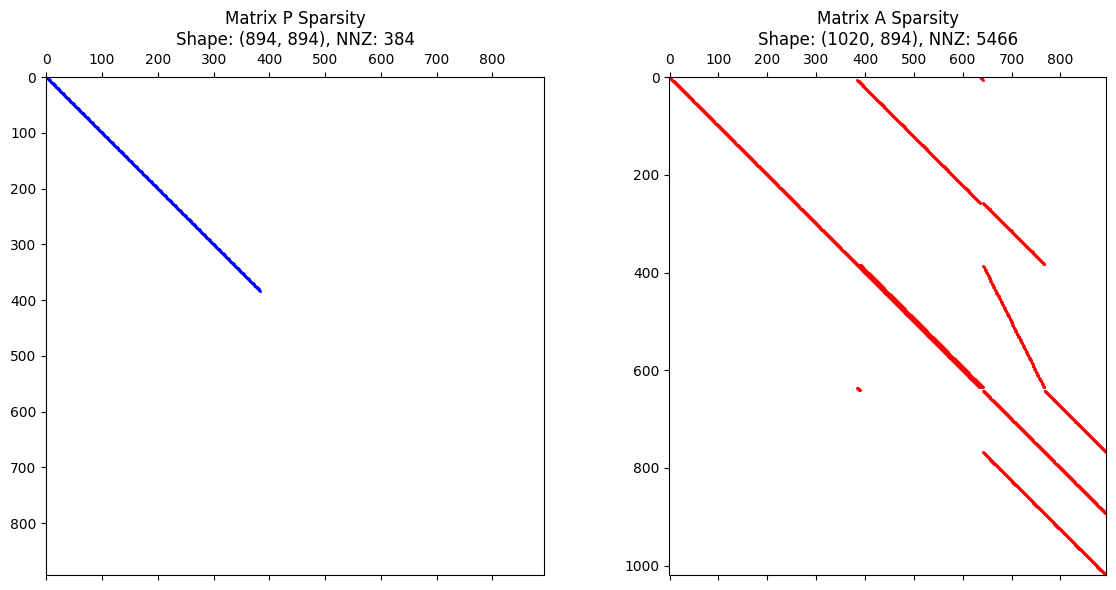


--- SCS (Indirect PCG) ---
Total Python time: 98.559 ms
Internal C time:   66.102 ms
Objective value:   260.761305

CVXPY
Solve time: 19.416 ms
Objective function value: 260.464376


CVXPYgen
Solve time: 5.567 ms
Objective function value: 260.464360



In [4]:
from MPC_code.cpg_solver import cpg_solve
import numpy as np
import pickle
import time

# load the serialized problem formulation
with open('MPC_code/problem.pickle', 'rb') as f:
    prob = pickle.load(f)

# assign parameter values
prob.param_dict['A'].value = np.eye(n)+td*A_cont
prob.param_dict['B'].value = td*B_cont
prob.param_dict['Psqrt'].value = np.eye(n)
prob.param_dict['Qsqrt'].value = np.eye(n)
prob.param_dict['Rsqrt'].value = np.sqrt(0.1)*np.eye(m)
prob.param_dict['x_init'].value = np.array([2, 2, 2, -1, -1, 1])



import scipy.sparse as sp
import numpy as np
import cvxpy as cp

# Canonicalize to OSQP standard form
data, chain, inverse_data = problem.get_problem_data(cp.OSQP)

# Extract matrices
P = data['P']
q = data['q']
A_eq = data['A']
b = data['b']

F = data['F']
G = data['G']

# Build full OSQP constraint matrix
A_osqp = sp.vstack([A_eq, F]).tocsc()

# Equality constraints: A_eq x = b
l_eq = b
u_eq = b

# Inequality constraints: F x <= G
n_ineq = F.shape[0]
l_ineq = -np.inf * np.ones(n_ineq)
u_ineq = G

# Final OSQP bounds
l = np.hstack([l_eq, l_ineq])
u = np.hstack([u_eq, u_ineq])

# Print dimensions
print("P shape:", P.shape)
print("q shape:", q.shape)
print("A shape:", A_osqp.shape)
print("l shape:", l.shape)
print("u shape:", u.shape)

# Export sparse matrices
sp.save_npz("data/P.npz", P)
sp.save_npz("data/A.npz", A_osqp)

# Export vectors
np.save("data/q.npy", q)
np.save("data/l.npy", l)
np.save("data/u.npy", u)

print("\nExported OSQP canonicalized QP data.")


import scipy.sparse as sp
import matplotlib.pyplot as plt

# Load your extracted matrices (if running separately)
# P = sp.load_npz("data/P.npz")
# A_osqp = sp.load_npz("data/A.npz")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot the sparsity pattern of P
# markersize controls how big the dots are. Lower it if the matrix is huge.
ax1.spy(P, markersize=1, color='blue')
ax1.set_title(f"Matrix P Sparsity\nShape: {P.shape}, NNZ: {P.nnz}")

# Plot the sparsity pattern of A
ax2.spy(A_osqp, markersize=1, color='red')
ax2.set_title(f"Matrix A Sparsity\nShape: {A_osqp.shape}, NNZ: {A_osqp.nnz}")

plt.tight_layout()
plt.show()



# 2. Solve problem with SCS (Indirect / PCG)
t0 = time.time()
# Note: SCS uses 'max_iters' instead of 'max_iter'
val_scs = prob.solve(solver=cp.SCS, use_indirect=True, eps_abs=1e-3, eps_rel=1e-3, max_iters=4000)
t1 = time.time()
print('\n--- SCS (Indirect PCG) ---')
print('Total Python time: %.3f ms' % (1000 * (t1 - t0)))
if prob.solver_stats:
    print('Internal C time:   %.3f ms' % (prob.solver_stats.solve_time * 1000))
print('Objective value:   %.6f' % val_scs)



# solve problem conventionally
t0 = time.time()
# CVXPY chooses eps_abs=eps_rel=1e-5, max_iter=10000, polish=True by default,
# however, we choose the OSQP default values here, as they are used for code generation as well
val = prob.solve(eps_abs=1e-3, eps_rel=1e-3, max_iter=4000, polish=False)
t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))
print('Objective function value: %.6f\n' % val)

# solve problem with C code via python wrapper
prob.register_solve('CPG', cpg_solve)
t0 = time.time()
val = prob.solve(method='CPG')
t1 = time.time()
print('\nCVXPYgen\nSolve time: %.3f ms' % (1000 * (t1 - t0)))
print('Objective function value: %.6f\n' % val)

\[1\] Wang, Yang, and Stephen Boyd. "Fast model predictive control using online optimization." IEEE Transactions on control systems technology 18.2 (2009): 267-278.

\[2\] Hovgaard, T. G., Larsen, L. F., Jørgensen, J. B., and Boyd, S.  "MPC for wind power gradients—utilizing forecasts, rotor inertia, and central energy storage." 2013 European Control Conference (ECC). IEEE, 2013.